In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("titanic.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
print(df.describe(include="all"))

        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male   
freq            NaN         NaN         NaN                    1   577   
mean     446.000000    0.383838    2.308642                  NaN   NaN   
std      257.353842    0.486592    0.836071                  NaN   NaN   
min        1.000000    0.000000    1.000000                  NaN   NaN   
25%      223.500000    0.000000    2.000000                  NaN   NaN   
50%      446.000000    0.000000    3.000000                  NaN   NaN   
75%      668.500000    1.000000    3.000000                  NaN   NaN   
max      891.000000    1.000000    3.000000                  NaN   NaN   

               Age       SibSp       Parch  Ticket        Fare Cabin Embarked  
count   714.000000  891.000000 

In [6]:
target_column = "Survived"

print("Target Column:", target_column)
print(df[target_column].value_counts())

Target Column: Survived
Survived
0    549
1    342
Name: count, dtype: int64


In [7]:
X = df.drop(columns=[target_column])
y = df[target_column]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 11)
Target Shape: (891,)


In [8]:
X = pd.get_dummies(X, drop_first=True)

print("New Features Shape:", X.shape)
X.head()

New Features Shape: (891, 1725)


,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,38.0,1,0,71.2833,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,3,26.0,0,0,7.9250,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,35.0,1,0,53.1000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,3,35.0,0,0,8.0500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [9]:
X = X.fillna(X.median(numeric_only=True))

In [10]:
print("Missing Values After Cleaning:")
print(X.isnull().sum().sum())

Missing Values After Cleaning:
0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 1725)
Testing data: (179, 1725)


In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [13]:
predictions = model.predict(X_test)

print("Predictions:")
print(predictions[:20])

Predictions:
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [14]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average="weighted", zero_division=0)
recall = recall_score(y_test, predictions, average="weighted", zero_division=0)
f1 = f1_score(y_test, predictions, average="weighted", zero_division=0)

print("Model Performance")
print("------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Model Performance
------------------
Accuracy  : 0.8156
Precision : 0.8152
Recall    : 0.8156
F1-Score  : 0.8120


In [15]:
print(classification_report(y_test, predictions, zero_division=0))


              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



In [16]:
print(classification_report(y_test, predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



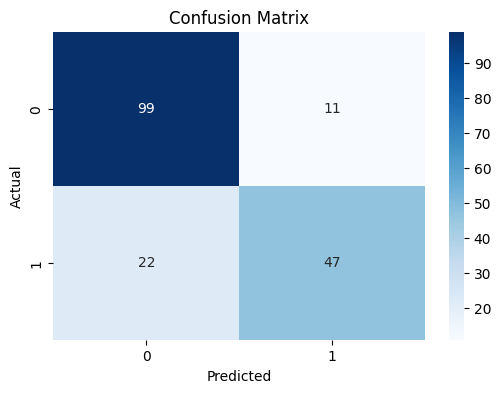

In [17]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

In [19]:
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(
    y_test,
    dt_predictions,
    average="weighted",
    zero_division=0
)
dt_recall = recall_score(
    y_test,
    dt_predictions,
    average="weighted",
    zero_division=0
)
dt_f1 = f1_score(
    y_test,
    dt_predictions,
    average="weighted",
    zero_division=0
)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1-Score  : {dt_f1:.4f}")

Decision Tree Performance
-------------------------
Accuracy  : 0.7374
Precision : 0.7398
Recall    : 0.7374
F1-Score  : 0.7384


In [20]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]
})

comparison

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.815642,0.737430
1,Precision,0.815161,0.739804
2,Recall,0.815642,0.737430
3,F1-Score,0.812048,0.738408


In [21]:
if f1 >= dt_f1:
    print("Logistic Regression performed better based on F1-Score.")
else:
    print("Decision Tree performed better based on F1-Score.")

Logistic Regression performed better based on F1-Score.
